## ⚽📊 Evaluating Passing Decisions Using xPass, xThreat & Machine Learning

**Competition:** Premier League (Season 2024/25)  
**Data:** SkillCorner Dynamic Events Data  
**Purpose:** Evaluate passing decisions by estimating the value of all available passing options  
**Methods:** Pass Completion Modelling (xPass), Expected Threat (xThreat), Gradient Boosting Models, Neural Networks  
**Author:** [Victoria Friss de Kereki](https://www.linkedin.com/in/victoria-friss-de-kereki/)

---

**Notebook first written:** `14/03/2026`  
**Last updated:** `18/03/2026`  

---

> Passing is the most common action in football, yet evaluating whether a player made the best decision in possession is difficult.
>
> Using SkillCorner Dynamic Events Data from the 2024/25 Premier League season, this notebook estimates the value of all available passing options for each possession event.
>
> A machine learning model predicts pass completion probability (xPass) using spatial and contextual features. This probability is combined with expected threat (xThreat) to estimate the expected value of each potential pass.
>
> By comparing the value of the pass that was played to the best available option, we can quantify decision quality and analyse which players consistently make better passing decisions.

## Imports & Display Settings

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set(style="whitegrid", font_scale=1.2)

## Load data

### Events data

In [2]:
# Matches
matches = pd.read_parquet(r"Datasets/SkillCorner Premier League 24-25 data/matches_clean.parquet")

# Team lookup table
team_lookup = pd.concat([
    matches[["home_team_id","home_team_name"]].rename(columns={"home_team_id":"team_id","home_team_name":"team_name"}),
    matches[["away_team_id","away_team_name"]].rename(columns={"away_team_id":"team_id","away_team_name":"team_name"})
]).drop_duplicates()

# Event files
folder = Path(r"Datasets/SkillCorner Premier League 24-25 data\dynamic_events_pl_24\dynamic")
dfs = [pd.read_parquet(file) for file in folder.glob("*.parquet")]
events = pd.concat(dfs, ignore_index=True)

print(f"Total events: {len(events)}, Unique matches: {events['match_id'].nunique()}")

Total events: 1811078, Unique matches: 378


In [3]:
# Basic dataset information
print("Number of rows:", events.shape[0])
print("Number of columns:", events.shape[1])

# Display column names
events.columns

Number of rows: 1811078
Number of columns: 294


Index(['event_id', 'index', 'match_id', 'frame_start', 'frame_end',
       'frame_physical_start', 'time_start', 'time_end', 'minute_start',
       'second_start',
       ...
       'xloss_player_possession_end', 'xloss_player_possession_max',
       'xshot_player_possession_start', 'xshot_player_possession_end',
       'xshot_player_possession_max', 'is_player_possession_start_matched',
       'is_player_possession_end_matched', 'is_previous_pass_matched',
       'is_pass_reception_matched', 'fully_extrapolated'],
      dtype='object', length=294)

In [4]:
events["event_type"].value_counts().head(10)

event_type
passing_option        939059
player_possession     362853
on_ball_engagement    326100
off_ball_run          183066
Name: count, dtype: int64

In [5]:
events.head()

,event_id,index,match_id,frame_start,frame_end,frame_physical_start,time_start,time_end,minute_start,second_start,...,xloss_player_possession_end,xloss_player_possession_max,xshot_player_possession_start,xshot_player_possession_end,xshot_player_possession_max,is_player_possession_start_matched,is_player_possession_end_matched,is_previous_pass_matched,is_pass_reception_matched,fully_extrapolated
0,8_0,0,1650385,52,52,NaN,00:04.2,00:04.2,0,4,...,NaN,NaN,NaN,NaN,NaN,True,True,None,True,False
1,1_0,1,1650385,59,72,NaN,00:04.9,00:06.2,0,4,...,NaN,NaN,NaN,NaN,NaN,True,True,None,None,None
2,8_1,2,1650385,62,71,NaN,00:05.2,00:06.1,0,5,...,NaN,NaN,NaN,NaN,NaN,True,True,True,True,False
3,7_0,3,1650385,62,70,NaN,00:05.2,00:06.0,0,5,...,NaN,NaN,NaN,NaN,NaN,True,True,None,None,False
4,9_0,4,1650385,62,71,59.0,00:04.9,00:06.1,0,4,...,0.03,0.092,0.0,0.0,0.0,True,True,True,True,None


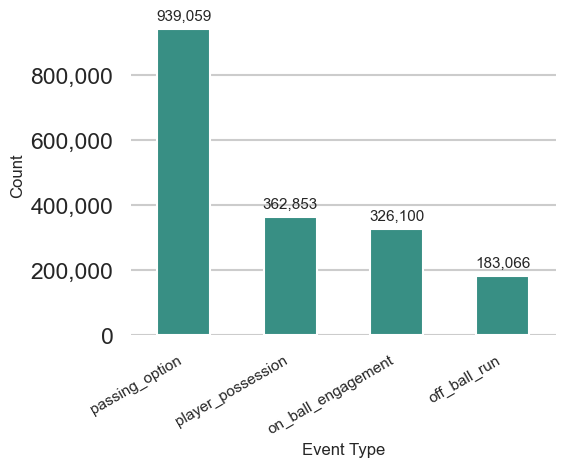

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Style and context
sns.set_style("whitegrid")
sns.set_context("talk")

# Example: top 4 event types (replace with your actual data)
top_events = events["event_type"].value_counts().nlargest(4).index

# Figure size: narrower height, wider width for few bars
plt.figure(figsize=(6, 5))

# Vertical bar plot
ax = sns.countplot(
    data=events,
    x="event_type",
    order=top_events,
    color="#2a9d8f",  # modern teal colour
    width=0.5          # narrower bars for nice spacing
)

# Add counts on top of bars with thousands separator
max_count = events["event_type"].value_counts().max()
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + max_count * 0.02,  # slightly above bar
        f'{int(height):,}',          # thousands separator
        ha='center', va='bottom', fontsize=11
    )

# Format y-axis with thousands separator
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

# Labels
ax.set_xlabel("Event Type", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

# Rotate x labels slightly if needed
plt.xticks(rotation=30, ha='right', fontsize=11)

# Remove unnecessary spines
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

### Players match data

In [7]:
# LOAD PLAYERS MATCH DATA

players_match = pd.read_parquet(
    "Datasets/SkillCorner Premier League 24-25 data/players_match.parquet"
)

players_match["player_id"] = players_match["id"]
players_match["player_name"] = players_match["short_name"]
players_match["position"] = players_match["player_role_acronym"]
players_match["position_group"] = players_match["player_role_position_group"]


# MINUTES SUMMARY PER PLAYER

minutes_summary = (
    players_match
    .groupby(["player_id","player_name"])
    .agg(
        minutes_tip=("playing_time_total_minutes_tip","sum"),
        minutes_otip=("playing_time_total_minutes_otip","sum"),
        minutes_played=("playing_time_total_minutes_played","sum")
    )
    .reset_index()
)


# MINUTES PLAYED BY POSITION

position_minutes = (
    players_match
    .groupby(
        ["player_id","player_name","position","position_group"],
        as_index=False
    )
    .agg(
        minutes_played=("playing_time_total_minutes_played","sum")
    )
)

position_minutes_sorted = position_minutes.sort_values(
    ["player_id","minutes_played"],
    ascending=[True,False]
)


# FUNCTION TO GET MAIN POSITION (WITH SUB FIX)

def get_main_position(df):

    main_pos = df.iloc[0]["position"]
    pos_group = df.iloc[0]["position_group"]

    # Fix substitute classification
    if main_pos == "SUB" and len(df) > 1:
        main_pos = df.iloc[1]["position"]
        pos_group = df.iloc[1]["position_group"]

    # Fix GK group naming
    if main_pos == "GK":
        pos_group = "Goalkeeper"

    return pd.Series({
        "main_position": main_pos,
        "position_group": pos_group
    })


main_positions = (
    position_minutes_sorted
    .groupby("player_id")
    .apply(get_main_position)
    .reset_index()
)


# FINAL PLAYER DATASET

players = (
    minutes_summary
    .merge(main_positions, on="player_id", how="left")
)


# Prevent division by zero later
players["minutes_played"] = players["minutes_played"].replace(0, np.nan)

print(players.shape)
players.head()

(686, 7)


C:\Users\vicky\AppData\Local\Temp\ipykernel_33824\802975726.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(get_main_position)


,player_id,player_name,minutes_tip,minutes_otip,minutes_played,main_position,position_group
0,82,A. Cresswell,240.62,280.86,937.72,LCB,Central Defender
1,124,A. Doucouré,649.13,886.57,2792.56,AM,Midfield
2,168,A. Armstrong,395.59,356.80,1381.38,CF,Center Forward
3,192,A. Lallana,125.61,124.60,429.45,LM,Midfield
4,209,A. Smith,436.55,478.56,1753.84,RB,Full Back


## Player Passing Analysis

In [8]:
# PASSING DECISION & OPTION CREATION ANALYSIS
# xThreat × xPass

# 1️⃣ Passing options dataset

passing_options = events[events["event_type"] == "passing_option"].copy()

# Identify passer vs receiver

passing_options["passer_id"] = passing_options["player_in_possession_id"]
passing_options["passer_name"] = passing_options["player_in_possession_name"]

passing_options["receiver_id"] = passing_options["player_id"]
passing_options["receiver_name"] = passing_options["player_name"]


# 2️⃣ Pass value

passing_options["pass_value"] = (passing_options["xthreat"] * passing_options["xpass_completion"])


# 3️⃣ Best option available in each pass

best_option = (
    passing_options
    .groupby(
        ["match_id","associated_player_possession_event_id"],
        as_index=False
    )
    .agg(best_pass_value=("pass_value","max"))
)

passing_options = passing_options.merge(
    best_option,
    on=["match_id","associated_player_possession_event_id"],
    how="left"
)



# 4️⃣ Extract actual passes

chosen_passes = passing_options[
    passing_options["targeted"] == True
].copy()


print("Total passes analysed:", len(chosen_passes))

Total passes analysed: 306382


In [11]:
# Remove irrelevant columns

passing_options = passing_options.dropna(axis=1, how="all")
print("Remaining columns:", len(passing_options.columns))

Remaining columns: 153


In [15]:
columns_keep = [

    # identifiers
    "match_id",
    "event_id",
    "associated_player_possession_event_id",

    # passer / receiver
    "passer_id",
    "passer_name",
    "receiver_id",
    "receiver_name",

    # team
    "team_id",
    "team_shortname",

    # timing
    "minute_start",
    "second_start",
    "period",

    # locations
    "x_start",
    "y_start",
    "x_end",
    "y_end",

    # spatial context
    "third_start",
    "third_end",
    "channel_start",
    "channel_end",

    # pass characteristics
    "pass_distance",
    "pass_angle",
    "pass_direction",
    "pass_ahead",

    # defensive context
    "n_opponents_ahead_player_in_possession_pass_moment",
    "n_opponents_bypassed",

    # model outputs
    "xpass_completion",
    "xthreat",
    "pass_value",
    "best_pass_value",
    "passing_option_score",

    # pass decision
    "targeted",
    "received",
    "received_in_space",
    "dangerous",
    "difficult_pass_target",

    # option context
    "n_simultaneous_passing_options"
]

passing_options = passing_options[columns_keep]

print("Columns kept:", len(passing_options.columns))

Columns kept: 37


In [16]:
passing_options.head(10)

,match_id,event_id,associated_player_possession_event_id,passer_id,passer_name,receiver_id,receiver_name,team_id,team_shortname,minute_start,second_start,period,x_start,y_start,x_end,y_end,third_start,third_end,channel_start,channel_end,pass_distance,pass_angle,pass_direction,pass_ahead,n_opponents_ahead_player_in_possession_pass_moment,n_opponents_bypassed,xpass_completion,xthreat,pass_value,best_pass_value,passing_option_score,targeted,received,received_in_space,dangerous,difficult_pass_target,n_simultaneous_passing_options
0,1650385,7_0,8_1,13068.0,S. Lukić,12941,E. Smith Rowe,48,Fulham,0,5,1,-3.81,7.10,-5.88,3.57,middle_third,middle_third,center,center,NaN,NaN,None,True,10.0,0.0,0.9808,0.0013,0.001275,0.001300,0.7928,False,False,None,False,False,3.0
1,1650385,7_1,8_1,13068.0,S. Lukić,5794,K. Tete,48,Fulham,0,5,1,-12.58,-19.43,-12.75,-19.66,middle_third,middle_third,half_space_right,half_space_right,NaN,NaN,None,False,10.0,0.0,0.9972,0.0001,0.000100,0.001300,0.9321,False,False,None,False,False,3.0
2,1650385,7_2,8_1,13068.0,S. Lukić,4504,I. Diop,48,Fulham,0,5,1,-22.51,-6.97,-22.68,-7.03,defensive_third,defensive_third,center,center,12.66,-161.01,backward,False,10.0,0.0,0.9989,0.0000,0.000000,0.001300,0.7076,True,True,True,False,False,3.0
3,1650385,7_3,8_1,13068.0,S. Lukić,12168,Adama Traoré,48,Fulham,0,6,1,4.61,-26.95,4.61,-26.95,middle_third,middle_third,wide_right,wide_right,NaN,NaN,None,True,10.0,4.0,0.6190,0.0021,0.001300,0.001300,0.7342,False,False,None,False,True,3.0
4,1650385,7_4,8_2,4504.0,I. Diop,32264,C. Bassey,48,Fulham,0,7,1,-27.70,10.34,-28.16,10.63,defensive_third,defensive_third,half_space_left,half_space_left,NaN,NaN,None,False,10.0,0.0,0.9986,0.0000,0.000000,0.001429,0.8665,False,False,None,False,False,1.0
5,1650385,7_5,8_2,4504.0,I. Diop,5794,K. Tete,48,Fulham,0,8,1,-15.94,-23.05,-13.21,-29.62,middle_third,middle_third,wide_right,wide_right,NaN,NaN,None,True,10.0,1.0,0.9421,0.0003,0.000283,0.001429,0.8669,False,False,None,False,False,4.0
6,1650385,7_6,8_2,4504.0,I. Diop,11438,Andreas Pereira,48,Fulham,0,8,1,-5.98,-11.54,-10.79,-16.03,middle_third,middle_third,half_space_right,half_space_right,NaN,NaN,None,True,10.0,4.0,0.9747,0.0007,0.000682,0.001429,0.7970,False,False,None,False,False,3.0
7,1650385,7_7,8_2,4504.0,I. Diop,12168,Adama Traoré,48,Fulham,0,10,1,8.01,-32.90,9.04,-32.63,middle_third,middle_third,wide_right,wide_right,30.26,-17.18,forward,True,10.0,6.0,0.4291,0.0020,0.000858,0.001429,0.9208,True,True,False,False,True,3.0
8,1650385,7_8,8_2,4504.0,I. Diop,32862,Rodrigo Muniz,48,Fulham,0,10,1,10.77,-8.40,10.99,-9.64,middle_third,middle_third,center,half_space_right,NaN,NaN,None,True,10.0,6.0,0.5103,0.0028,0.001429,0.001429,0.8554,False,False,None,False,True,3.0
9,1650385,7_9,8_3,12168.0,Adama Traoré,5794,K. Tete,48,Fulham,0,13,1,-3.57,-29.34,1.71,-28.64,middle_third,middle_third,wide_right,wide_right,NaN,NaN,None,False,4.0,-2.0,0.9211,0.0020,0.001842,0.005579,0.9390,False,False,None,False,False,2.0


In [24]:
chosen_passes = chosen_passes[columns_keep]
chosen_passes.head()

,match_id,event_id,associated_player_possession_event_id,passer_id,passer_name,receiver_id,receiver_name,team_id,team_shortname,minute_start,second_start,period,x_start,y_start,x_end,y_end,third_start,third_end,channel_start,channel_end,pass_distance,pass_angle,pass_direction,pass_ahead,n_opponents_ahead_player_in_possession_pass_moment,n_opponents_bypassed,xpass_completion,xthreat,pass_value,best_pass_value,passing_option_score,targeted,received,received_in_space,dangerous,difficult_pass_target,n_simultaneous_passing_options
2,1650385,7_2,8_1,13068.0,S. Lukić,4504,I. Diop,48,Fulham,0,5,1,-22.51,-6.97,-22.68,-7.03,defensive_third,defensive_third,center,center,12.66,-161.01,backward,False,10.0,0.0,0.9989,0.0000,0.000000,0.001300,0.7076,True,True,True,False,False,3.0
7,1650385,7_7,8_2,4504.0,I. Diop,12168,Adama Traoré,48,Fulham,0,10,1,8.01,-32.90,9.04,-32.63,middle_third,middle_third,wide_right,wide_right,30.26,-17.18,forward,True,10.0,6.0,0.4291,0.0020,0.000858,0.001429,0.9208,True,True,False,False,True,3.0
15,1650385,7_15,8_4,70672.0,K. Mainoo,6847,M. Rashford,31,Manchester U,0,15,1,-2.29,28.59,-6.47,32.18,middle_third,middle_third,wide_left,wide_left,7.17,-19.98,forward,True,8.0,3.0,0.5425,0.0028,0.001519,0.002538,0.9013,True,True,True,False,True,3.0
17,1650385,7_17,8_6,1674.0,Casemiro,6847,M. Rashford,31,Manchester U,0,21,1,5.33,31.06,5.33,31.06,middle_third,middle_third,wide_left,wide_left,NaN,NaN,None,True,7.0,7.0,0.3618,0.0217,0.007851,0.007851,0.8663,True,False,None,True,True,0.0
19,1650385,7_19,8_9,12380.0,N. Mazraoui,24305,A. Diallo,31,Manchester U,1,9,1,-18.64,-4.71,-19.33,-13.33,defensive_third,defensive_third,center,half_space_right,7.29,158.68,backward,False,7.0,-1.0,0.9706,0.0006,0.000582,0.002118,0.9305,True,True,True,False,False,1.0


In [28]:
# DECISION METRICS

chosen_passes["decision_quality"] = (
    chosen_passes["pass_value"] /
    chosen_passes["best_pass_value"].replace(0, np.nan)
)

# If pass is within 95% of best, it is still considered the best.
chosen_passes["chose_best"] = (
    chosen_passes["pass_value"] >=
    chosen_passes["best_pass_value"] * 0.95
)


# EXECUTION METRICS


chosen_passes["actual_completion"] = (
    chosen_passes["received"] == True
).astype(int)

chosen_passes["completion_minus_xpass"] = (
    chosen_passes["actual_completion"] -
    chosen_passes["xpass_completion"]
)

In [29]:
chosen_passes.head()

,match_id,event_id,associated_player_possession_event_id,passer_id,passer_name,receiver_id,receiver_name,team_id,team_shortname,minute_start,second_start,period,x_start,y_start,x_end,y_end,third_start,third_end,channel_start,channel_end,pass_distance,pass_angle,pass_direction,pass_ahead,n_opponents_ahead_player_in_possession_pass_moment,n_opponents_bypassed,xpass_completion,xthreat,pass_value,best_pass_value,passing_option_score,targeted,received,received_in_space,dangerous,difficult_pass_target,n_simultaneous_passing_options,decision_quality,chose_best,actual_completion,completion_minus_xpass
2,1650385,7_2,8_1,13068.0,S. Lukić,4504,I. Diop,48,Fulham,0,5,1,-22.51,-6.97,-22.68,-7.03,defensive_third,defensive_third,center,center,12.66,-161.01,backward,False,10.0,0.0,0.9989,0.0000,0.000000,0.001300,0.7076,True,True,True,False,False,3.0,0.000000,False,1,0.0011
7,1650385,7_7,8_2,4504.0,I. Diop,12168,Adama Traoré,48,Fulham,0,10,1,8.01,-32.90,9.04,-32.63,middle_third,middle_third,wide_right,wide_right,30.26,-17.18,forward,True,10.0,6.0,0.4291,0.0020,0.000858,0.001429,0.9208,True,True,False,False,True,3.0,0.600627,False,1,0.5709
15,1650385,7_15,8_4,70672.0,K. Mainoo,6847,M. Rashford,31,Manchester U,0,15,1,-2.29,28.59,-6.47,32.18,middle_third,middle_third,wide_left,wide_left,7.17,-19.98,forward,True,8.0,3.0,0.5425,0.0028,0.001519,0.002538,0.9013,True,True,True,False,True,3.0,0.598392,False,1,0.4575
17,1650385,7_17,8_6,1674.0,Casemiro,6847,M. Rashford,31,Manchester U,0,21,1,5.33,31.06,5.33,31.06,middle_third,middle_third,wide_left,wide_left,NaN,NaN,None,True,7.0,7.0,0.3618,0.0217,0.007851,0.007851,0.8663,True,False,None,True,True,0.0,1.000000,True,0,-0.3618
19,1650385,7_19,8_9,12380.0,N. Mazraoui,24305,A. Diallo,31,Manchester U,1,9,1,-18.64,-4.71,-19.33,-13.33,defensive_third,defensive_third,center,half_space_right,7.29,158.68,backward,False,7.0,-1.0,0.9706,0.0006,0.000582,0.002118,0.9305,True,True,True,False,False,1.0,0.275020,False,1,0.0294


In [30]:
# PLAYER PASSING METRICS

passer_metrics = (
    chosen_passes
    .groupby(["passer_id","passer_name","team_shortname"])
    .agg(
        passes_attempted=("pass_value","count"),

        # decision making
        avg_decision_quality=("decision_quality","mean"),
        chose_best_rate=("chose_best","mean"),
        chose_best_count=("chose_best","sum"),
        chose_not_best_count=("chose_best", lambda x: (~x).sum()),

        # execution
        completion_minus_xpass_per_pass=("completion_minus_xpass","mean"),
        completion_minus_xpass_total=("completion_minus_xpass","sum"),

        # value
        total_pass_value=("pass_value","sum"),
        avg_pass_value=("pass_value","mean"),
    )
    .reset_index()
)

In [31]:
passer_metrics.head()

,passer_id,passer_name,team_shortname,passes_attempted,avg_decision_quality,chose_best_rate,chose_best_count,chose_not_best_count,completion_minus_xpass_per_pass,completion_minus_xpass_total,total_pass_value,avg_pass_value
0,82.0,A. Cresswell,West Ham,487,0.645213,0.449692,219,268,0.001779,0.8663,1.375383,0.002824
1,124.0,A. Doucouré,Everton,838,0.677176,0.461814,387,451,-0.009749,-8.1696,6.445650,0.007692
2,168.0,A. Armstrong,Southampton,262,0.638158,0.393130,103,159,-0.020382,-5.3400,2.595092,0.009905
3,192.0,A. Lallana,Southampton,244,0.677934,0.442623,108,136,0.017164,4.1881,1.385082,0.005677
4,209.0,A. Smith,Bournemouth,470,0.611951,0.408511,192,278,-0.011119,-5.2257,1.697833,0.003612


In [34]:
# MERGE PLAYER DATA (TIP minutes)

passer_metrics = passer_metrics.merge(
    players,
    left_on="passer_id",
    right_on="player_id",
    how="left"
)


# NORMALISE PER 90 TIP

passer_metrics["passes_per90_tip"] = (
    passer_metrics["passes_attempted"] /
    passer_metrics["minutes_tip"] * 90
)

passer_metrics["pass_value_per90_tip"] = (
    passer_metrics["total_pass_value"] /
    passer_metrics["minutes_tip"] * 90
)


# FILTER SMALL SAMPLE PLAYERS

passers_filtered = passer_metrics[
    passer_metrics["passes_attempted"] >= 200
].copy()

passer_metrics.head()

,passer_id,passer_name,team_shortname,passes_attempted,avg_decision_quality,chose_best_rate,chose_best_count,chose_not_best_count,completion_minus_xpass_per_pass,completion_minus_xpass_total,total_pass_value,avg_pass_value,player_id,player_name,minutes_tip,minutes_otip,minutes_played,main_position,position_group,passes_per90_tip,pass_value_per90_tip
0,82.0,A. Cresswell,West Ham,487,0.645213,0.449692,219,268,0.001779,0.8663,1.375383,0.002824,82,A. Cresswell,240.62,280.86,937.72,LCB,Central Defender,182.154434,0.514440
1,124.0,A. Doucouré,Everton,838,0.677176,0.461814,387,451,-0.009749,-8.1696,6.445650,0.007692,124,A. Doucouré,649.13,886.57,2792.56,AM,Midfield,116.186280,0.893671
2,168.0,A. Armstrong,Southampton,262,0.638158,0.393130,103,159,-0.020382,-5.3400,2.595092,0.009905,168,A. Armstrong,395.59,356.80,1381.38,CF,Center Forward,59.607169,0.590405
3,192.0,A. Lallana,Southampton,244,0.677934,0.442623,108,136,0.017164,4.1881,1.385082,0.005677,192,A. Lallana,125.61,124.60,429.45,LM,Midfield,174.826845,0.992416
4,209.0,A. Smith,Bournemouth,470,0.611951,0.408511,192,278,-0.011119,-5.2257,1.697833,0.003612,209,A. Smith,436.55,478.56,1753.84,RB,Full Back,96.896117,0.350029


In [32]:
# RECEIVER PASSING OPTION METRICS

receiver_metrics = (
    passing_options
    .groupby(["receiver_id","receiver_name","team_shortname"])
    .agg(

        # availability
        passing_options_available=("receiver_id","count"),

        # how often teammates choose them
        times_targeted=("targeted","sum"),

        # rate they are chosen when available
        option_selection_rate=("targeted","mean"),

        # value of those options
        total_option_value=("pass_value","sum"),
        avg_option_value=("pass_value","mean"),

        # threat potential
        total_xthreat_available=("xthreat","sum"),
        avg_xthreat_available=("xthreat","mean"),

        # pass difficulty
        avg_xpass_passing_option_created=("xpass_completion","mean"),
    )
    .reset_index()
)

In [33]:
receiver_metrics.head()

,receiver_id,receiver_name,team_shortname,passing_options_available,times_targeted,option_selection_rate,total_option_value,avg_option_value,total_xthreat_available,avg_xthreat_available,avg_xpass_passing_option_created
0,82,A. Cresswell,West Ham,985,421,0.427411,2.333095,0.002369,2.9246,0.002969,0.948263
1,124,A. Doucouré,Everton,3334,918,0.275345,28.352796,0.008504,49.1876,0.014753,0.741333
2,168,A. Armstrong,Southampton,1547,406,0.262443,19.010562,0.012289,36.0667,0.023314,0.682346
3,192,A. Lallana,Southampton,721,232,0.321775,4.008802,0.005560,5.5767,0.007735,0.865946
4,209,A. Smith,Bournemouth,1444,412,0.285319,5.536435,0.003834,7.3042,0.005058,0.903156


In [35]:
# MERGE PLAYER DATA (TIP minutes)

receiver_metrics = receiver_metrics.merge(
    players,
    left_on="receiver_id",
    right_on="player_id",
    how="left"
)


# NORMALISE PER 90 TIP

receiver_metrics["options_available_per90_tip"] = (
    receiver_metrics["passing_options_available"] /
    receiver_metrics["minutes_tip"] * 90
)

receiver_metrics["targets_received_per90_tip"] = (
    receiver_metrics["times_targeted"] /
    receiver_metrics["minutes_tip"] * 90
)

receiver_metrics["option_value_per90_tip"] = (
    receiver_metrics["total_option_value"] /
    receiver_metrics["minutes_tip"] * 90
)

receiver_metrics["xthreat_available_per90_tip"] = (
    receiver_metrics["total_xthreat_available"] /
    receiver_metrics["minutes_tip"] * 90
)


# FILTER SMALL SAMPLE PLAYERS

receivers_filtered = receiver_metrics[
    receiver_metrics["passing_options_available"] >= 200
].copy()

receiver_metrics.head()

,receiver_id,receiver_name,team_shortname,passing_options_available,times_targeted,option_selection_rate,total_option_value,avg_option_value,total_xthreat_available,avg_xthreat_available,avg_xpass_passing_option_created,player_id,player_name,minutes_tip,minutes_otip,minutes_played,main_position,position_group,options_available_per90_tip,targets_received_per90_tip,option_value_per90_tip,xthreat_available_per90_tip
0,82,A. Cresswell,West Ham,985,421,0.427411,2.333095,0.002369,2.9246,0.002969,0.948263,82,A. Cresswell,240.62,280.86,937.72,LCB,Central Defender,368.423240,157.468207,0.872656,1.093899
1,124,A. Doucouré,Everton,3334,918,0.275345,28.352796,0.008504,49.1876,0.014753,0.741333,124,A. Doucouré,649.13,886.57,2792.56,AM,Midfield,462.249472,127.278049,3.931033,6.819719
2,168,A. Armstrong,Southampton,1547,406,0.262443,19.010562,0.012289,36.0667,0.023314,0.682346,168,A. Armstrong,395.59,356.80,1381.38,CF,Center Forward,351.955307,92.368361,4.325060,8.205473
3,192,A. Lallana,Southampton,721,232,0.321775,4.008802,0.005560,5.5767,0.007735,0.865946,192,A. Lallana,125.61,124.60,429.45,LM,Midfield,516.598997,166.228803,2.872320,3.995725
4,209,A. Smith,Bournemouth,1444,412,0.285319,5.536435,0.003834,7.3042,0.005058,0.903156,209,A. Smith,436.55,478.56,1753.84,RB,Full Back,297.697858,84.938724,1.141402,1.505848


## Result Tables & Visualisations

In [36]:
# ============================================
# TABLE 1 — Best Passing Decision Makers
# Players who most frequently choose the highest-value passing option
# ============================================

best_decision_makers = (
    passers_filtered
    .sort_values("chose_best_rate", ascending=False)
    [["passer_name","team_shortname","passes_attempted",
      "chose_best_rate","avg_decision_quality","pass_value_per90_tip"]]
    .head(15)
)

best_decision_makers

,passer_name,team_shortname,passes_attempted,chose_best_rate,avg_decision_quality,pass_value_per90_tip
79,M. Sels,Nottingham,403,0.620347,0.774388,0.047409
333,C. Chaplin,Ipswich Town,261,0.547893,0.715835,0.890677
80,M. Keane,Everton,313,0.546326,0.674739,0.163250
220,S. Botman,Newcastle,208,0.543269,0.700622,0.239958
58,J. Pickford,Everton,885,0.540113,0.669708,0.084968
136,D. Calvert-Lewin,Everton,218,0.536697,0.731633,0.533803
128,N. Pope,Newcastle,302,0.523179,0.618907,0.012107
271,M. Rogers,Aston Villa,815,0.521472,0.739097,1.209233
44,J. Vardy,Leicester,286,0.520979,0.723524,0.547693
253,E. Haaland,Manchester City,313,0.517572,0.737731,0.513281


In [37]:
# ============================================
# TABLE 2 — Players Creating the Most Passing Value
# Players whose passes generate the highest expected attacking value
# ============================================

top_value_passers = (
    passers_filtered
    .sort_values("pass_value_per90_tip", ascending=False)
    [["passer_name","team_shortname",
      "pass_value_per90_tip",
      "passes_per90_tip",
      "chose_best_rate"]]
    .head(15)
)

top_value_passers

,passer_name,team_shortname,pass_value_per90_tip,passes_per90_tip,chose_best_rate
62,K. De Bruyne,Manchester City,1.583442,130.795756,0.455193
82,Mohamed Salah,Liverpool,1.514292,91.221871,0.469558
103,I. Sarr,Crystal Palace,1.513038,94.235101,0.517442
94,T. Werner,Tottenham,1.475413,104.455260,0.437788
199,R. Nelson,Fulham,1.472441,141.843118,0.332061
14,Bruno Fernandes,Manchester U,1.468408,175.448666,0.455836
164,M. Gibbs-White,Nottingham,1.443586,157.456106,0.462979
241,M. Ødegaard,Arsenal,1.435254,145.223397,0.379545
256,M. Damsgaard,Brentford FC,1.425000,141.833811,0.486903
5,A. Iwobi,Fulham,1.393718,137.637738,0.443828


In [38]:
# ============================================
# TABLE 3 — Best Pass Execution (Completion vs xPass)
# Players who complete more passes than expected by the xPass model
# ============================================

best_executors = (
    passers_filtered
    .sort_values("completion_minus_xpass_per_pass", ascending=False)
    [["passer_name","team_shortname",
      "passes_attempted",
      "completion_minus_xpass_per_pass",
      "chose_best_rate"]]
    .head(15)
)

best_executors

,passer_name,team_shortname,passes_attempted,completion_minus_xpass_per_pass,chose_best_rate
190,K. Havertz,Arsenal,451,0.048143,0.463415
199,R. Nelson,Fulham,262,0.043253,0.332061
19,C. Nkunku,Chelsea,313,0.034535,0.389776
201,J. Sancho,Chelsea,773,0.032860,0.416559
237,Pedro Neto,Chelsea,780,0.032436,0.398718
37,Son Heung-Min,Tottenham,828,0.031804,0.405797
160,I. Sangaré,Nottingham,242,0.031774,0.433884
301,B. Saka,Arsenal,633,0.028425,0.382306
343,N. Domínguez,Nottingham,831,0.028400,0.438026
192,C. Nørgaard,Brentford FC,1261,0.023855,0.445678


In [40]:
# ============================================
# TABLE 4 — Players Creating the Most Passing Options
# Players who most frequently make themselves available for passes
# ============================================

top_option_creators = (
    receivers_filtered
    .sort_values("options_available_per90_tip", ascending=False)
    [["receiver_name","team_shortname",
      "options_available_per90_tip",
      "targets_received_per90_tip",
      "option_selection_rate"]]
    .head(15)
)

top_option_creators

,receiver_name,team_shortname,options_available_per90_tip,targets_received_per90_tip,option_selection_rate
351,A. Irving,West Ham,563.388626,193.720379,0.343849
567,J. Simpson-Pusey,Manchester City,559.459459,170.27027,0.304348
268,E. Buendía,Aston Villa,542.289667,144.610578,0.266667
96,T. Cairney,Fulham,534.253471,201.996896,0.378092
527,L. Miley,Newcastle,534.021009,149.900634,0.280702
36,H. Reed,Fulham,529.973475,107.427056,0.202703
439,N. Broadhead,Ipswich Town,525.269307,131.679082,0.250689
520,R. Esse,Crystal Palace,516.770893,140.704946,0.272277
3,A. Lallana,Southampton,516.598997,166.228803,0.321775
48,J. Schlupp,Crystal Palace,505.541562,131.486146,0.26009


In [41]:
# ============================================
# TABLE 5 — Most Valuable Passing Options Created
# Players whose movement creates the highest-value passing options
# ============================================

best_off_ball_value = (
    receivers_filtered
    .sort_values("option_value_per90_tip", ascending=False)
    [["receiver_name","team_shortname",
      "option_value_per90_tip",
      "options_available_per90_tip",
      "targets_received_per90_tip"]]
    .head(15)
)

best_off_ball_value

,receiver_name,team_shortname,option_value_per90_tip,options_available_per90_tip,targets_received_per90_tip
488,Ali Al Hamadi,Ipswich Town,9.077111,495.104895,151.048951
182,T. Awoniyi,Nottingham,8.710155,433.092726,149.083842
15,C. Wilson,Newcastle,8.590106,378.538048,101.578344
32,E. Ünal,Bournemouth,8.579459,426.555427,137.392385
563,C. Obi,Manchester U,8.138038,413.729697,79.987741
449,D. Jebbison,Bournemouth,7.871798,382.207578,100.494234
358,D. Núñez,Liverpool,7.708126,404.503950,93.461702
466,J. Durán,Aston Villa,7.409776,435.021971,113.187535
27,Diogo Jota,Liverpool,7.160354,430.782580,103.42159
509,Igor Thiago,Brentford FC,7.142652,366.678225,88.938974


In [42]:
# ============================================
# TABLE 6 — Most Dangerous Receiving Positions
# Players who generate the most expected threat through their availability
# ============================================

dangerous_receivers = (
    receivers_filtered
    .sort_values("xthreat_available_per90_tip", ascending=False)
    [["receiver_name","team_shortname",
      "xthreat_available_per90_tip",
      "targets_received_per90_tip",
      "option_selection_rate"]]
    .head(15)
)

dangerous_receivers

,receiver_name,team_shortname,xthreat_available_per90_tip,targets_received_per90_tip,option_selection_rate
182,T. Awoniyi,Nottingham,19.394225,149.083842,0.344231
15,C. Wilson,Newcastle,19.278459,101.578344,0.268344
488,Ali Al Hamadi,Ipswich Town,19.044336,151.048951,0.305085
32,E. Ünal,Bournemouth,17.408733,137.392385,0.322097
563,C. Obi,Manchester U,16.503678,79.987741,0.193333
358,D. Núñez,Liverpool,16.029725,93.461702,0.231053
372,Evanilson,Bournemouth,16.018981,103.253587,0.267932
399,N. Jackson,Chelsea,15.255620,104.125474,0.27792
466,J. Durán,Aston Villa,15.178221,113.187535,0.260188
198,C. Wood,Nottingham,15.099404,115.135797,0.289769


In [ ]:
# ==========================================================
# SCATTER 2 — Passing Value vs Execution Skill
# Separates decision quality from technical execution
# ==========================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=passers_filtered,
    x="avg_pass_value",
    y="completion_minus_xpass_per_pass",
    hue="position_group",
    palette=palette,
    alpha=0.85,
    s=70
)

plt.axhline(0, linestyle="--", color="grey")

# label top 3 executors
top3 = passers_filtered.nlargest(3, "completion_minus_xpass_per_pass")

for _, r in top3.iterrows():
    plt.text(
        r["avg_pass_value"] + 0.0001,
        r["completion_minus_xpass_per_pass"] + 0.002,
        r["passer_name"],
        fontsize=10,
        weight="bold"
    )

plt.xlabel("Average Pass Value")
plt.ylabel("Completion minus xPass")
plt.title("Pass Value vs Execution Skill")

plt.legend(
    title="Position Group",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# SCATTER 2 — Passing Value vs Execution Skill
# Separates decision quality from technical execution
# ==========================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=passers_filtered,
    x="avg_pass_value",
    y="completion_minus_xpass_per_pass",
    hue="position_group",
    palette=palette,
    alpha=0.85,
    s=70
)

plt.axhline(0, linestyle="--", color="grey")

# label top 3 executors
top3 = passers_filtered.nlargest(3, "completion_minus_xpass_per_pass")

for _, r in top3.iterrows():
    plt.text(
        r["avg_pass_value"] + 0.0001,
        r["completion_minus_xpass_per_pass"] + 0.002,
        r["passer_name"],
        fontsize=10,
        weight="bold"
    )

plt.xlabel("Average Pass Value")
plt.ylabel("Completion minus xPass")
plt.title("Pass Value vs Execution Skill")

plt.legend(
    title="Position Group",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# SCATTER 3 — Off-ball Availability vs Teammate Trust
# Are players who get open actually chosen by teammates?
# ==========================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=receivers_filtered,
    x="options_available_per90_tip",
    y="option_selection_rate",
    hue="position_group",
    palette=palette,
    alpha=0.85,
    s=70
)

plt.axhline(receivers_filtered["option_selection_rate"].mean(), linestyle="--", color="grey")
plt.axvline(receivers_filtered["options_available_per90_tip"].mean(), linestyle="--", color="grey")

# label top 3 option creators
top3 = receivers_filtered.nlargest(3, "options_available_per90_tip")

for _, r in top3.iterrows():
    plt.text(
        r["options_available_per90_tip"] + 0.2,
        r["option_selection_rate"] + 0.002,
        r["receiver_name"],
        fontsize=10,
        weight="bold"
    )

plt.xlabel("Passing Options Created per 90")
plt.ylabel("Selection Rate")
plt.title("Off-ball Availability vs Teammate Trust")

plt.legend(
    title="Position Group",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# SCATTER 4 — Dangerous Receiving Positions
# Players who both create dangerous options and receive passes
# ==========================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=receivers_filtered,
    x="xthreat_available_per90_tip",
    y="targets_received_per90_tip",
    hue="position_group",
    palette=palette,
    alpha=0.85,
    s=70
)

# label top 3 threat creators
top3 = receivers_filtered.nlargest(3, "xthreat_available_per90_tip")

for _, r in top3.iterrows():
    plt.text(
        r["xthreat_available_per90_tip"] + 0.02,
        r["targets_received_per90_tip"] + 0.2,
        r["receiver_name"],
        fontsize=10,
        weight="bold"
    )

plt.xlabel("xThreat Available per 90")
plt.ylabel("Targets Received per 90")
plt.title("Dangerous Receiving Positions")

plt.legend(
    title="Position Group",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# SCATTER 5 — xThreat vs xPass (Pass Value Components)
# Examines the trade-off between threat and completion probability
# ==========================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=passing_options,
    x="xpass_completion",
    y="xthreat",
    alpha=0.25,
    s=25,
    color="#1982c4"
)

# highlight most valuable passes
top_value = passing_options.nlargest(3, "pass_value")

sns.scatterplot(
    data=top_value,
    x="xpass_completion",
    y="xthreat",
    color="red",
    s=120
)

for _, r in top_value.iterrows():
    plt.text(
        r["xpass_completion"] + 0.002,
        r["xthreat"] + 0.0002,
        r["receiver_name"],
        fontsize=10,
        weight="bold"
    )

plt.xlabel("xPass Completion Probability")
plt.ylabel("Expected Threat (xThreat)")
plt.title("Pass Value Components: Threat vs Completion Probability")

plt.tight_layout()
plt.show()